# Stellar EOS

A stellar equation of state describing a multi-component plasma (ions, electrons, and radiation) is available
via the {py:obj}`StellarEOS <pynucastro.eos.stellar_eos.StellarEOS>` class.

```{note}
Presently, the equation of state does not include Coulomb corrections.
```

In [1]:
import pynucastro as pyna

In [2]:
eos = pyna.StellarEOS()

In [3]:
comp = pyna.Composition(["he4"])
comp.set_equal()

## Exploring stability

A star is unstable if the adiabatic index, $\Gamma_1$, drops below 4/3.  We can map out the region in the thermodynamic plane where this happens.

In [4]:
import numpy as np

In [5]:
Ts = np.logspace(5, 10, 36)
rhos = np.logspace(-2, 9, 67)

In [6]:
gamma1 = np.zeros((len(rhos), len(Ts)))

In [7]:
for ir, rho in enumerate(rhos):
    for it, T in enumerate(Ts):
        state = eos.pe_state(rho, T, comp)
        gamma1[ir, it] = state.gamma1


In [8]:
import matplotlib.pyplot as plt

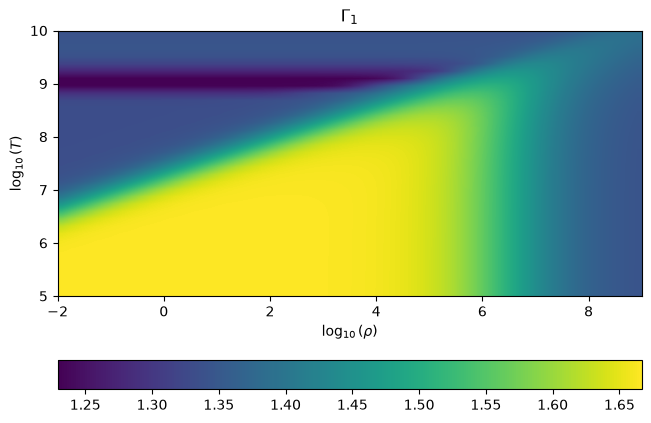

In [9]:
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111)
im = ax.imshow(gamma1.T, origin="lower",
               extent=[np.log10(rhos.min()), np.log10(rhos.max()),
                       np.log10(Ts.min()), np.log10(Ts.max())],
               interpolation="bilinear")
ax.set_xlabel(r"$\log_{10}(\rho)$")
ax.set_ylabel(r"$\log_{10}(T)$")
ax.set_title(r"$\Gamma_1$")
fig.colorbar(im, ax=ax, orientation="horizontal")

In [10]:
fig.savefig("eos.pdf", bbox_inches="tight")